Swept 837 central pressures in 64.4s
Mmax = 2.774 Msun at R = 13.370 km
Near M=1.4 Msun: R=14.813 km  beta=0.1409  yR=0.5242  k2=0.1008  lambda=4.7943e+04 km^5
Saved mrk2_test.png
Plot 0
x limits: (np.float64(7.8), np.float64(17.5))
y limits: (np.float64(0.0), np.float64(3.0))
Plot 1
x limits: (np.float64(-0.01176043655908833), np.float64(0.32157465586404493))
y limits: (np.float64(-0.005425711234969375), np.float64(0.121582278577136))
Plot 2
x limits: (np.float64(-0.02200606029310638), np.float64(2.9074640809400263))
y limits: (np.float64(4748.461281152797), np.float64(69493.00825176646))
Plot 3
x limits: (np.float64(0.38), np.float64(2.02))
y limits: (np.float64(10.0), np.float64(600000.0))


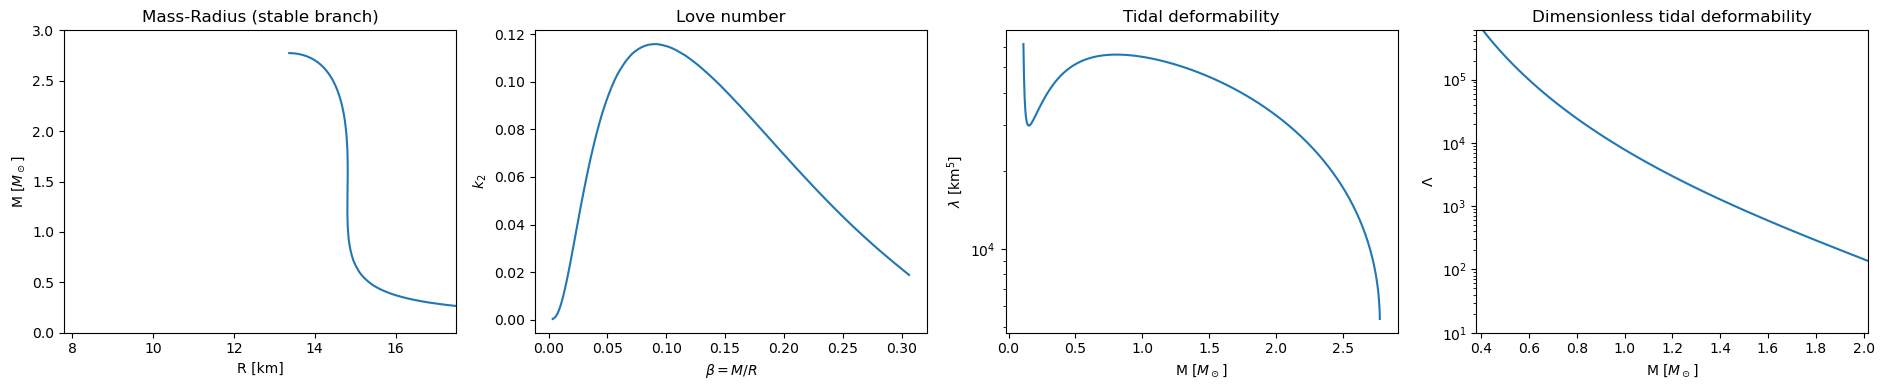

In [6]:
#Needed libraries
import numpy as np
from scipy.constants import G, c, pi
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline, PchipInterpolator
import matplotlib.pyplot as plt
import time
import mpmath as mp

#All the constants needed
Msol = 1.98847 * 10**30 #kg
R0 = 2 * G * Msol / (c**2 * 1000) #km
P0SI = c**8 / (32 * pi * G**3 * Msol**2) #Pascals
P0 = P0SI / (1.602176634 * 10**32) #MeV/fm^3

# ---------------------------------------------------------------------------
# k2(beta, yR) -- Eq. (2) of Postnikov, Prakash & Lattimer (2010), 1004.5098.
# Evaluated in arbitrary precision below beta=0.05 because the closed-form
# expression suffers catastrophic cancellation as beta -> 0 (subtracting two
# nearly-equal large terms in double precision). Low-mass/large-radius stars
# from a central-pressure sweep routinely land in that regime, so this isn't
# an edge case you can ignore.
# ---------------------------------------------------------------------------
def _k2_formula(beta, yR, dps=None):
    if dps is None:
        b, y = beta, yR
        term1 = 2 - y + 2*b*(y - 1)
        bracket = (2*b*(6 - 3*y + 3*b*(5*y - 8)
                         + 2*b**2*(13 - 11*y + b*(3*y - 2)
                                   + 2*b**2*(1 + y)))
                   + 3*(1 - 2*b)**2*term1*np.log(1 - 2*b))
        return (8.0/5.0)*b**5*(1 - 2*b)**2*term1 / bracket
    else:
        with mp.workdps(dps):
            b, y = mp.mpf(beta), mp.mpf(yR)
            term1 = 2 - y + 2*b*(y - 1)
            bracket = (2*b*(6 - 3*y + 3*b*(5*y - 8)
                             + 2*b**2*(13 - 11*y + b*(3*y - 2)
                                       + 2*b**2*(1 + y)))
                       + 3*(1 - 2*b)**2*term1*mp.log(1 - 2*b))
            return float(mp.mpf(8)/5*b**5*(1 - 2*b)**2*term1/bracket)

def love_number_k2(beta, yR, small_beta_cutoff=0.05):
    if beta < small_beta_cutoff:
        return _k2_formula(beta, yR, dps=50)
    return _k2_formula(beta, yR)


# This is where you replace the " " place with whatever tabular EOS file name
def EOStoObservables(EOS, r_cut_km=50.0):
    tabEOS = np.loadtxt(EOS, skiprows = 4)
    energyd = tabEOS[:,0]
    pressure = tabEOS[:,1]
    numd = tabEOS[:,2]
    #Scaling the values in the tabEOS
    energydbar = energyd / P0
    pressurebar = pressure / P0
    assert np.all(np.diff(pressurebar) > 0), "Pressure column is not strictly increasing"
    assert np.all(np.diff(energydbar) > 0), "Energy density column is not strictly increasing"
    #Interpolate log(ebar) vs log(Pbar) with a MONOTONIC (Pchip) interpolant.
    #Real EOS tables are close to power laws and often have kinks (e.g. where
    #a crust table is stitched to a core model) -- an ordinary cubic spline
    #in *linear* P,e space rings/overshoots at those kinks, and since cs2 is
    #a *derivative* of this interpolant, that ringing gets amplified into
    #wild cs2 swings and a noisy/spiky k2(beta) curve. Log-log + Pchip (which
    #is built to never overshoot) fixes both the shape mismatch and the
    #ringing.
    logPbar = np.log(pressurebar)
    logebar = np.log(energydbar)
    logE_of_logP = PchipInterpolator(logPbar, logebar, extrapolate=False)
    dlogE_dlogP = logE_of_logP.derivative(1)

    def pressureToEnergyd(Pbar_eval):
        return np.exp(logE_of_logP(np.log(Pbar_eval)))

    Pbar_min = pressurebar.min()
    Pbar_max = pressurebar.max()

    def cs2_from_Pbar(Pbar_eval):
        # cs2 = dP/de = (e/P) / (dloge/dlogP)
        lp = np.log(Pbar_eval)
        slope = dlogE_dlogP(lp)
        if slope <= 0:
            return 1e10  # near-incompressible fallback
        ebar = np.exp(logE_of_logP(lp))
        return float((Pbar_eval / ebar) / slope)

    #TOV + y(r) equations, all in Mbar/Rbar/Pbar/ebar variables
    def TOV(Rbar, y):
        Mbar, Pbar, yL = y
        Pbar_eval = max(Pbar, Pbar_min)
        ebar = pressureToEnergyd(Pbar_eval)
        cs2 = cs2_from_Pbar(Pbar_eval)

        dMbar_dRbar = ebar * Rbar**2
        dPbar_dRbar = -1 * (Mbar * ebar / (2 * Rbar**2)) * (1 + Pbar / ebar) * (1 + Rbar**3 * Pbar / Mbar) * (1 - Mbar / Rbar)**-1

        # e^lambda = 1/(1-2m/r) becomes 1/(1-Mbar/Rbar) in this scaling,
        # exactly as in the (1-Mbar/Rbar)**-1 factor above.
        ELAM = 1.0 / (1.0 - Mbar / Rbar)

        # Derived by substituting r=R0*Rbar, m=(R0/2)*Mbar, p=Pbar/(8*pi*R0^2),
        # rho=ebar/(8*pi*R0^2) into Eqs. (3)-(6) of 1004.5098 -- R0 cancels
        # completely, as it must since y is dimensionless and its ODE can only
        # depend on the dimensionless state variables.
        y_elam_term = 1.0 + 0.5 * Rbar**2 * (Pbar - ebar)
        Q_bracket = 5*ebar + 9*Pbar + (ebar + Pbar) / cs2
        r2Q = 0.5 * Rbar**2 * ELAM * Q_bracket - 6*ELAM \
              - (ELAM**2 / Rbar**2) * (Mbar + Rbar**3 * Pbar)**2

        dyL_dRbar = -(1.0 / Rbar) * (yL**2 + yL * ELAM * y_elam_term + r2Q)

        return [dMbar_dRbar, dPbar_dRbar, dyL_dRbar]
    
    #Pressure tracking for solver to stop when it reaches 0
    def surface(Rbar, y):
        Mbar, Pbar, yL = y
        return Pbar
    surface.terminal = True
    surface.direction = -1
    
    #Initial Conditions
    def collapsed_star(Pbar_c):
        #Make sure Pbar_c is in the EOS
        assert Pbar_min <= Pbar_c <= Pbar_max, f"Pbar_c={Pbar_c} outside table range [{Pbar_min}, {Pbar_max}]"
        ebar_c = pressureToEnergyd(Pbar_c)
        Rbar0 = 10**-6
        Mbar0 = ebar_c * Rbar0**3 / 3
        y0 = [Mbar0, Pbar_c, 2.0]  # y(0) = 2, Eq. (12) boundary condition -- invariant under rescaling
        #Just to make the code work
        Rbar_max = 5000
        #Solving
        sol = solve_ivp(TOV, (Rbar0, Rbar_max), y0, method='RK45', events=surface, rtol = 10**-8, atol = 10**-10)
        #In case the solution didnt trigger the event, meaning its working wrong and reached dummy Rbar_max limit
        if not sol.success or len(sol.t_events[0]) == 0:
            return None
        #Getting solutions at the exact surface crossing (more accurate than the last integrator step)
        Rbarf = sol.t_events[0][0]
        Mbarf, Pbarf, yRbar = sol.y_events[0][0]
        R = Rbarf * R0
        M = Mbarf

        #Compactness: 2*m_geom/r_geom = Mbar/Rbar in this scaling (see derivation
        #above), so beta = GM/(Rc^2) = m_geom/r_geom = Mbar/(2*Rbar)
        beta = Mbarf / (2.0 * Rbarf)
        try:
            k2 = love_number_k2(beta, yRbar)
        except (ZeroDivisionError, ValueError):
            return None  # pathological yR from the noisy low-density branch
        if not np.isfinite(k2):
            return None
        lam = (2.0 / 3.0) * k2 * R**5  # km^5, G=c=1 convention

        return R, M, beta, yRbar, k2, lam
    
    #Sweep over all Pbar_c except those too close to the surface and the highest densities
    Pbar_c_values = np.logspace(np.log10(Pbar_min) + 2, np.log10(Pbar_max) - 0.1, 1000)
    results = []
    for Pc in Pbar_c_values:
        out = collapsed_star(Pc)
        if out is not None:
            R, M, beta, yRbar, k2, lam = out
            results.append((Pc, R, M, beta, yRbar, k2, lam))
    results = np.array(results)
    if results.size == 0:
        raise RuntimeError("No central pressures produced a valid stellar solution — check Rbar_max or the EOS table.")
    Pcs, Rs, Ms, betas, yRs, k2s, lams = results.T

    #Dimensionless tidal deformability, Lambda = lambda / M_geom^5.
    #lambda is already in km^5 (G=c=1 convention); M_geom is the mass
    #converted from solar masses into the SAME geometrized length units
    #(km), M_geom = M[Msun] * (R0/2), since R0 = 2*G*Msol/c^2.
    M_geom_km = Ms * (R0 / 2.0)
    Lambdas = lams / M_geom_km**5

    #Gets the maximum mass for the EOS
    idx_max = np.argmax(Ms)

    #Physical branch selection, two parts:
    #  (1) R < r_cut_km: real EOS tables often extend down to near-vacuum
    #      density, where central pressures barely above the table's floor
    #      integrate out to enormous, physically meaningless radii (not
    #      "real" white-dwarf-like structure, just numerical extension of
    #      an almost-pressureless gas ball). r_cut_km=50 is generous --
    #      real NS/WD radii from a core-EOS table stay well under this.
    #  (2) walk backward from Mmax while mass is still increasing with Pc:
    #      removes the unstable (dM/dPc<0) branch past the maximum mass,
    #      which doesn't correspond to real stars either.
    valid = Rs < r_cut_km
    if not np.any(valid[:idx_max + 1]):
        stable = slice(idx_max, idx_max + 1)  # degenerate fallback
    else:
        start = idx_max
        while start > 0 and (Ms[start - 1] < Ms[start]) and valid[start - 1]:
            start -= 1
        stable = slice(start, idx_max + 1)

    return {
        "Pcs": Pcs, "Rs": Rs, "Ms": Ms, "betas": betas, "yRs": yRs,
        "k2s": k2s, "lambdas": lams, "Lambdas": Lambdas,
        "Mmax": Ms[idx_max], "Rmax": Rs[idx_max], "idx_max": idx_max,
        "stable": stable,  # slice object -- e.g. out["Ms"][out["stable"]]
    }





#Code for visualizing results in plots/graphs


#The below code in 'if _name_' runs if I run the entire cell, outputting the graphs listed below for a single EOS file.
if __name__ == "__main__":
    t0 = time.time()
    #Replace EOSName with the name of the EOS file to create the graphs of M-R, k2-B, dimensionful lambda-M, and dimensionlass lambda-M
    out = EOStoObservables("EOSBetaNL3.dat")
    print(f"Swept {len(out['Pcs'])} central pressures in {time.time()-t0:.1f}s")
    print(f"Mmax = {out['Mmax']:.3f} Msun at R = {out['Rmax']:.3f} km")

    i14 = np.argmin(np.abs(out["Ms"] - 1.4))
    print(f"Near M=1.4 Msun: R={out['Rs'][i14]:.3f} km  beta={out['betas'][i14]:.4f}  "
          f"yR={out['yRs'][i14]:.4f}  k2={out['k2s'][i14]:.4f}  lambda={out['lambdas'][i14]:.4e} km^5")

    s = out["stable"]
    fig, axes = plt.subplots(1, 4, figsize=(19, 4))
    axes[0].plot(out["Rs"][s], out["Ms"][s])
    #Change the values in the setlims from whatever to whatever if you want to customize from where to where your axes are. If you want to let it be uniform according to the data, just delete them and let python do its thing.
    axes[0].set_xlim(7.8, 17.5)
    axes[0].set_ylim(0, 3)
    axes[0].set_xlabel("R [km]"); axes[0].set_ylabel(r"M [$M_\odot$]"); axes[0].set_title("Mass-Radius (stable branch)")

    axes[1].plot(out["betas"][s], out["k2s"][s])
    axes[1].set_xlabel(r"$\beta = M/R$"); axes[1].set_ylabel(r"$k_2$"); axes[1].set_title("Love number")

    axes[2].plot(out["Ms"][s], out["lambdas"][s])
    axes[2].set_yscale("log")
    axes[2].set_xlabel(r"M [$M_\odot$]"); axes[2].set_ylabel(r"$\lambda$ [km$^5$]"); axes[2].set_title("Tidal deformability")

    axes[3].plot(out["Ms"][s], out["Lambdas"][s])
    axes[3].set_xlim(0.38, 2.02)
    axes[3].set_ylim(10, 600000)
    axes[3].set_yscale("log")
    axes[3].set_xlabel(r"M [$M_\odot$]"); axes[3].set_ylabel(r"$\Lambda$"); axes[3].set_title("Dimensionless tidal deformability")

    plt.tight_layout()
    plt.savefig("mrk2_test.png", dpi=120)
    print("Saved mrk2_test.png")
    for i, ax in enumerate(axes):
        print(f"Plot {i}")
        print("x limits:", ax.get_xlim())
        print("y limits:", ax.get_ylim())

#The compare_eos is a method, so I have to call it with inputs in the form of compare_eos(["IUFSU.dat", "FSUGarnet.dat", "RMF022.dat"],labels=["IUFSU", "FSUGarnet", "RMF022"]) for it to create a file with the generated graph.
#This is useful because I can import this method from this file into other files to use just this method
def compare_eos(eos_files, labels=None, r_cut_km=50.0, savepath="eos_comparison.png"):
    """
    Overlay multiple EOS curves on the same M-R / Lambda-M / Lambda-R axes,
    in the style of papers like the one you're checking against (panel a:
    M vs R; panel b: Lambda vs M and Lambda vs R side by side).
 
    eos_files: list of paths to tabulated EOS files (same format as
               EOStoObservables expects)
    labels: optional list of legend labels (defaults to filenames)
    """
    if labels is None:
        labels = [f.split("/")[-1] for f in eos_files]
 
    #A fixed color cycle so each EOS gets a distinct, consistent color
    #across all three panels (matplotlib's default cycle repeats after 10,
    #which is enough for a typical EOS comparison; pass your own list of
    #hex colors here if you have more than 10 EOS).
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
    all_results = {}
    for i, (fname, label) in enumerate(zip(eos_files, labels)):
        color = colors[i % len(colors)]
        out = EOStoObservables(fname, r_cut_km=r_cut_km)
        all_results[label] = out
        s = out["stable"]
 
        axes[0].plot(out["Rs"][s], out["Ms"][s], color=color, label=label)
        axes[1].plot(out["Ms"][s], out["Lambdas"][s], color=color, label=label)
        axes[2].plot(out["Rs"][s], out["Lambdas"][s], color=color, label=label)
 
    axes[0].set_xlabel(r"R [km]"); axes[0].set_ylabel(r"M [$M_\odot$]")
    axes[0].set_ylim(bottom=0)
 
    axes[1].set_xlabel(r"M [$M_\odot$]"); axes[1].set_ylabel(r"$\Lambda$")
    axes[1].set_yscale("log")
 
    axes[2].set_xlabel(r"R [km]"); axes[2].set_ylabel(r"$\Lambda$")
    axes[2].set_yscale("log")
 
    axes[0].legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    return all_results